# Adaptive Guardrail Layer (AGL) - Anomaly Detection Notebook

## Purpose
This notebook develops and compares unsupervised anomaly detection models for malicious prompt detection using the engineered feature dataset. It is kept compatible with Google Colab and assumes the input dataset is available at `/content/dataset_feature_engineered.csv`.

## Goals
- Load the engineered dataset
- Build a benign-only training set for anomaly detection
- Compare various models
- Tune thresholds on validation data
- Evaluate final model behavior on held-out test data

## Expected input
- `dataset_feature_engineered.csv`

In [2]:
import os
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.feature_selection import VarianceThreshold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

VAL_SIZE = 0.20
TEST_SIZE = 0.20

# runtime controls
MAX_BENIGN_TRAIN_SAMPLES_IF = None
MAX_BENIGN_TRAIN_SAMPLES_LOF = 80000
BATCH_SIZE = 256

# autoencoder controls
AE_EPOCHS = 120
AE_PATIENCE = 12
AE_LEARNING_RATE = 8e-4
AE_WEIGHT_DECAY = 1e-5
AE_NOISE_STD = 0.03

THRESHOLD_OBJECTIVE = "f1"   # f1 or recall_priority
MIN_RECALL = 0.70

### Load data

In [4]:
INPUT_PATH = "../../data/processed/"
INPUT_FILENAME = Path(INPUT_PATH) / "dataset_feature_engineered.csv"

if not os.path.exists(INPUT_FILENAME):
    raise FileNotFoundError(f"Could not find input file: {INPUT_FILENAME}")

df = pd.read_csv(INPUT_FILENAME)
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Loaded dataset: 104,755 rows x 74 columns


,row_id,prompt,label,source_dataset,char_length,word_count,avg_word_length,line_count,sentence_count,token_count,...,embed_pca_23,embed_pca_24,embed_pca_25,embed_pca_26,embed_pca_27,embed_pca_28,embed_pca_29,embed_pca_30,embed_pca_31,embed_pca_32
0,0,Here's what I need you to do for me: 1. Transl...,0,WildGuardMix,220,45,3.911111,1,8,59,...,-0.024124,0.085803,-0.219357,-0.063032,-0.174054,-0.014205,0.049955,0.093883,0.005645,0.003084
1,1,I need some information quickly: 1. What is th...,0,WildGuardMix,188,36,4.250000,1,8,48,...,0.120953,-0.182473,-0.120312,0.031146,-0.101867,0.023967,-0.085226,0.004245,-0.079983,0.004235
2,2,Please do the following tasks: 1. Explain what...,0,WildGuardMix,159,29,4.517241,1,8,38,...,0.216458,0.016013,0.024323,-0.083344,-0.111400,0.011361,-0.002220,0.093972,-0.068973,0.044231
3,3,Could you help with these items? 1. Define 'Ma...,0,WildGuardMix,185,35,4.314286,1,9,50,...,0.111428,0.043126,-0.114772,-0.082916,-0.109635,0.036963,-0.004525,-0.094766,-0.133499,-0.075309
4,4,I'm curious about a few things: 1. What's the ...,0,WildGuardMix,156,31,4.064516,1,8,48,...,0.126424,-0.039547,-0.020182,-0.033340,-0.072246,0.006569,-0.042061,0.071661,0.026669,0.036026


### Define columns for unsupervised training

In [6]:
target_column = "label"

feature_columns = [
    "token_count",
    "token_word_ratio",
    "whitespace_ratio",
    "punctuation_ratio",
    "special_char_ratio",
    "non_ascii_ratio",
    "markdown_symbol_count",
    "has_code_block",
    "repeated_punct_count",
    "quote_count",
    "bracket_count",
    "colon_count",
    "semicolon_count",
    "instruction_override_score",
    "roleplay_score",
    "payload_request_score",
    "social_engineering_score",
    "obfuscation_score",
    "has_instruction_override",
    "has_roleplay",
    "has_payload_request",
    "has_social_engineering",
    "has_obfuscation",
    "embedding_norm",
    "embed_pca_1",
    "embed_pca_2",
    "embed_pca_3",
    "embed_pca_4",
    "embed_pca_5",
    "embed_pca_6",
    "embed_pca_7",
    "embed_pca_8",
    "embed_pca_9",
    "embed_pca_10",
    "embed_pca_11",
    "embed_pca_12",
    "embed_pca_13",
    "embed_pca_14",
    "embed_pca_15",
    "embed_pca_16",
    "embed_pca_17",
    "embed_pca_18",
    "embed_pca_19",
    "embed_pca_20",
    "embed_pca_21",
    "embed_pca_22",
    "embed_pca_23",
    "embed_pca_24",
    "embed_pca_25",
    "embed_pca_26",
    "embed_pca_27",
    "embed_pca_28",
    "embed_pca_29",
    "embed_pca_30",
    "embed_pca_31",
    "embed_pca_32",
]
print(f"Total initial features: {len(feature_columns)}")

Total initial features: 56


### Train / validation / test split
- split on the full labeled dataset with stratification
- train unsupervised models (only on benign rows)
- keep validation/test untouched for threshold tuning and final evaluation

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=df[target_column],
    random_state=SEED,
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df[target_column],
    random_state=SEED,
)

train_benign_df = train_df.loc[train_df[target_column] == 0].copy()

print(f"Train rows (full): {len(train_df):,}")
print(f"Train benign rows: {len(train_benign_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Test rows: {len(test_df):,}")

print("\nValidation label distribution:")
print(val_df[target_column].value_counts(normalize=True).sort_index())

print("\nTest label distribution:")
print(test_df[target_column].value_counts(normalize=True).sort_index())

Train rows (full): 62,853
Train benign rows: 33,065
Validation rows: 20,951
Test rows: 20,951

Validation label distribution:
label
0    0.526037
1    0.473963
Name: proportion, dtype: float64

Test label distribution:
label
0    0.526085
1    0.473915
Name: proportion, dtype: float64


<!-- ### Feature cleanup on benign training data only
Two low-risk improvements for anomaly detection:
1. remove near-constant features
2. remove one feature from highly correlated pairs

Both steps are fit using only benign training rows. -->

### Shared helper functions

In [11]:
def evaluate_model(y_true, y_pred, model_name, split_name):
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n--- {model_name} ({split_name}) ---")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "model": model_name,
        "split": split_name,
        "f1": f1,
        "precision": prec,
        "recall": rec,
    }

def plot_score_distributions(y_true, scores, title):
    plt.figure(figsize=(10, 6))
    sns.histplot(scores[y_true == 0], label="Benign", alpha=0.5, stat="density", kde=True)
    sns.histplot(scores[y_true == 1], label="Malicious", alpha=0.5, stat="density", kde=True)
    plt.title(f"Score Distribution: {title}")
    plt.xlabel("Anomaly score")
    plt.legend()
    plt.show()

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def summarize_business_view(y_true, y_pred, positive_label_name="malicious"):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)

    print(f"Out of 100 {positive_label_name} prompts, the model catches about {round(rec * 100)}.")
    print(f"Out of 100 prompts flagged as {positive_label_name}, about {round(prec * 100)} are actually {positive_label_name}.")
    print(f"Confusion counts -> TP: {tp:,}, FN: {fn:,}, FP: {fp:,}, TN: {tn:,}")

def tune_threshold(y_true, scores, objective="f1", min_recall=0.60):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    precision = precision[:-1]
    recall = recall[:-1]
    thresholds = np.array(thresholds)

    if len(thresholds) == 0:
        fallback = np.percentile(scores[y_true == 0], 95)
        preds = (scores > fallback).astype(int)
        return {
            "threshold": float(fallback),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
        }

    f1_values = (2 * precision * recall) / (precision + recall + 1e-12)

    if objective == "recall_priority":
        valid = np.where(recall >= min_recall)[0]
        if len(valid) > 0:
            best_idx = valid[np.argmax(f1_values[valid])]
        else:
            best_idx = int(np.argmax(f1_values))
    else:
        best_idx = int(np.argmax(f1_values))

    best_threshold = float(thresholds[best_idx])
    best_preds = (scores > best_threshold).astype(int)

    return {
        "threshold": best_threshold,
        "precision": precision_score(y_true, best_preds, zero_division=0),
        "recall": recall_score(y_true, best_preds, zero_division=0),
        "f1": f1_score(y_true, best_preds, zero_division=0),
    }

def score_summary(y_true, scores):
    return {
        "roc_auc": roc_auc_score(y_true, scores),
        "avg_precision": average_precision_score(y_true, scores),
    }

def fit_scaler(name, X_train, X_val, X_test):
    if name == "robust":
        scaler = RobustScaler()
    elif name == "standard":
        scaler = StandardScaler()
    elif name == "quantile":
        scaler = QuantileTransformer(
            output_distribution="normal",
            n_quantiles=min(1000, max(100, len(X_train))),
            random_state=SEED,
        )
    else:
        raise ValueError(f"Unknown scaler: {name}")

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return scaler, X_train_scaled, X_val_scaled, X_test_scaled

def robust_zscore(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-9
    return 0.6745 * (x - med) / mad

### Feature Selection and Scaling

In [14]:
X_train_benign_selected = train_benign_df[feature_columns].copy()
X_val_selected = val_df[feature_columns].copy()
X_test_selected = test_df[feature_columns].copy()

y_val = val_df[target_column].astype(int).to_numpy()
y_test = test_df[target_column].astype(int).to_numpy()

scaler, X_train_scaled, X_val_scaled, X_test_scaled = fit_scaler(
    "quantile", 
    X_train_benign_selected,
    X_val_selected,
    X_test_selected,
)

print(f"Train benign shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Train benign shape: (33065, 56)
Validation shape: (20951, 56)
Test shape: (20951, 56)


## Unsupervised learning
This notebook explores four distinct models and selects the best-performing one:
1. Isolation Forest
2. Local Outlier Factor (novelty mode)
3. Denoising Deep Autoencoder  

### 1. Isolation Forest

In [17]:
print("Training and tuning Isolation Forest...")

X_train_if = X_train_scaled
if MAX_BENIGN_TRAIN_SAMPLES_IF is not None and len(X_train_if) > MAX_BENIGN_TRAIN_SAMPLES_IF:
    X_train_if = pd.DataFrame(X_train_if).sample(
        n=MAX_BENIGN_TRAIN_SAMPLES_IF,
        random_state=SEED,
    ).to_numpy()

if_params = {
    "n_estimators": [300, 500],
    "max_samples": ["auto", 0.8],
    "max_features": [0.8, 1.0],
    "bootstrap": [False, True],
    "contamination": ["auto", 0.01, 0.03],
}

best_if = None
best_if_model = None
best_if_scores_val = None

param_list = list(ParameterGrid(if_params))
total_runs = len(param_list)

for i, params in enumerate(param_list, 1):
    print(f"[{i}/{total_runs}] Isolation Forest params: {params}")

    candidate = IsolationForest(
        random_state=SEED,
        n_jobs=-1,
        **params,
    )
    candidate.fit(X_train_if)

    val_scores = -candidate.decision_function(X_val_scaled)
    threshold_info = tune_threshold(
        y_val,
        val_scores,
        objective=THRESHOLD_OBJECTIVE,
        min_recall=MIN_RECALL,
    )

    row = {
        "model": "Isolation Forest",
        **params,
        **threshold_info,
        **score_summary(y_val, val_scores),
    }

    print(
        f"   -> F1: {row['f1']:.4f} | Precision: {row['precision']:.4f} | "
        f"Recall: {row['recall']:.4f} | AP: {row['avg_precision']:.4f}"
    )

    if best_if is None or (row["f1"], row["avg_precision"]) > (best_if["f1"], best_if["avg_precision"]):
        best_if = row
        best_if_model = candidate
        best_if_scores_val = val_scores
        print(f"***New BEST Isolation Forest (F1: {row['f1']:.4f})")

display(pd.DataFrame([best_if]))

Training and tuning Isolation Forest...
[1/48] Isolation Forest params: {'bootstrap': False, 'contamination': 'auto', 'max_features': 0.8, 'max_samples': 'auto', 'n_estimators': 300}
   -> F1: 0.6779 | Precision: 0.5672 | Recall: 0.8423 | AP: 0.6709
   ✅ New BEST Isolation Forest (F1: 0.6779)
[2/48] Isolation Forest params: {'bootstrap': False, 'contamination': 'auto', 'max_features': 0.8, 'max_samples': 'auto', 'n_estimators': 500}
   -> F1: 0.6820 | Precision: 0.5745 | Recall: 0.8388 | AP: 0.6798
   ✅ New BEST Isolation Forest (F1: 0.6820)
[3/48] Isolation Forest params: {'bootstrap': False, 'contamination': 'auto', 'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 300}
   -> F1: 0.6937 | Precision: 0.5821 | Recall: 0.8584 | AP: 0.7228
   ✅ New BEST Isolation Forest (F1: 0.6937)
[4/48] Isolation Forest params: {'bootstrap': False, 'contamination': 'auto', 'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 500}
   -> F1: 0.6959 | Precision: 0.6066 | Recall: 0.8161 | AP: 0

,model,bootstrap,contamination,max_features,max_samples,n_estimators,threshold,precision,recall,f1,roc_auc,avg_precision
0,Isolation Forest,True,auto,1.0,0.8,500,-0.128215,0.582084,0.871601,0.698012,0.754499,0.732775


### 2. Local Outlier Factor in novelty mode

In [ ]:
print("Training and tuning Local Outlier Factor...")

X_train_lof = X_train_scaled
if MAX_BENIGN_TRAIN_SAMPLES_LOF is not None and len(X_train_lof) > MAX_BENIGN_TRAIN_SAMPLES_LOF:
    X_train_lof = pd.DataFrame(X_train_lof).sample(
        n=MAX_BENIGN_TRAIN_SAMPLES_LOF,
        random_state=SEED,
    ).to_numpy()

lof_params = {
    "n_neighbors": [15, 25, 35],
    "leaf_size": [20, 30],
    "metric": ["minkowski"],
    "p": [1, 2],
    "contamination": ["auto", 0.01, 0.03],
    "novelty": [True],
}

best_lof = None
best_lof_model = None
best_lof_scores_val = None

param_list = list(ParameterGrid(lof_params))
total_runs = len(param_list)

for i, params in enumerate(param_list, 1):
    print(f"[{i}/{total_runs}] LOF params: {params}")

    candidate = LocalOutlierFactor(**params)
    candidate.fit(X_train_lof)

    val_scores = -candidate.decision_function(X_val_scaled)
    threshold_info = tune_threshold(
        y_val,
        val_scores,
        objective=THRESHOLD_OBJECTIVE,
        min_recall=MIN_RECALL,
    )

    row = {
        "model": "Local Outlier Factor",
        **params,
        **threshold_info,
        **score_summary(y_val, val_scores),
    }

    print(
        f"   -> F1: {row['f1']:.4f} | Precision: {row['precision']:.4f} | "
        f"Recall: {row['recall']:.4f} | AP: {row['avg_precision']:.4f}"
    )

    if best_lof is None or (row["f1"], row["avg_precision"]) > (best_lof["f1"], best_lof["avg_precision"]):
        best_lof = row
        best_lof_model = candidate
        best_lof_scores_val = val_scores
        print(f"***New BEST LOF (F1: {row['f1']:.4f})")

display(pd.DataFrame([best_lof]))

Training and tuning Local Outlier Factor...
[1/36] LOF params: {'contamination': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 15, 'novelty': True, 'p': 1}
   -> F1: 0.6783 | Precision: 0.5849 | Recall: 0.8073 | AP: 0.7553
***New BEST LOF (F1: 0.6783)
[2/36] LOF params: {'contamination': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 15, 'novelty': True, 'p': 2}
   -> F1: 0.6488 | Precision: 0.5013 | Recall: 0.9192 | AP: 0.7336
[3/36] LOF params: {'contamination': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 25, 'novelty': True, 'p': 1}
   -> F1: 0.6794 | Precision: 0.5846 | Recall: 0.8110 | AP: 0.7568
***New BEST LOF (F1: 0.6794)
[4/36] LOF params: {'contamination': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 25, 'novelty': True, 'p': 2}
   -> F1: 0.6506 | Precision: 0.5010 | Recall: 0.9273 | AP: 0.7334
[5/36] LOF params: {'contamination': 'auto', 'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 35, 'novelty':

### 3. Denoising deep autoencoder

Using device: cpu
Training denoising autoencoder...
[Epoch 1/120] ✅ New BEST holdout loss: 0.373948
[Epoch 1/120] train_loss: 0.916523 | holdout_loss: 0.373948
[Epoch 2/120] ✅ New BEST holdout loss: 0.289334
[Epoch 3/120] ✅ New BEST holdout loss: 0.255895
[Epoch 4/120] ✅ New BEST holdout loss: 0.243650
[Epoch 5/120] ✅ New BEST holdout loss: 0.236429
[Epoch 6/120] ✅ New BEST holdout loss: 0.230486
[Epoch 7/120] ✅ New BEST holdout loss: 0.224633
[Epoch 8/120] ✅ New BEST holdout loss: 0.217543
[Epoch 9/120] ✅ New BEST holdout loss: 0.213948
[Epoch 10/120] ✅ New BEST holdout loss: 0.210764
[Epoch 10/120] train_loss: 0.222425 | holdout_loss: 0.210764
[Epoch 11/120] ✅ New BEST holdout loss: 0.207942
[Epoch 12/120] ✅ New BEST holdout loss: 0.203944
[Epoch 13/120] ✅ New BEST holdout loss: 0.202227
[Epoch 14/120] ✅ New BEST holdout loss: 0.201375
[Epoch 15/120] ✅ New BEST holdout loss: 0.198730
[Epoch 16/120] ✅ New BEST holdout loss: 0.198579
[Epoch 17/120] ✅ New BEST holdout loss: 0.195090
[Ep

,epoch,train_loss,holdout_loss
115,116,0.155554,0.146549
116,117,0.155182,0.146934
117,118,0.155267,0.146007
118,119,0.155222,0.145258
119,120,0.154876,0.146543


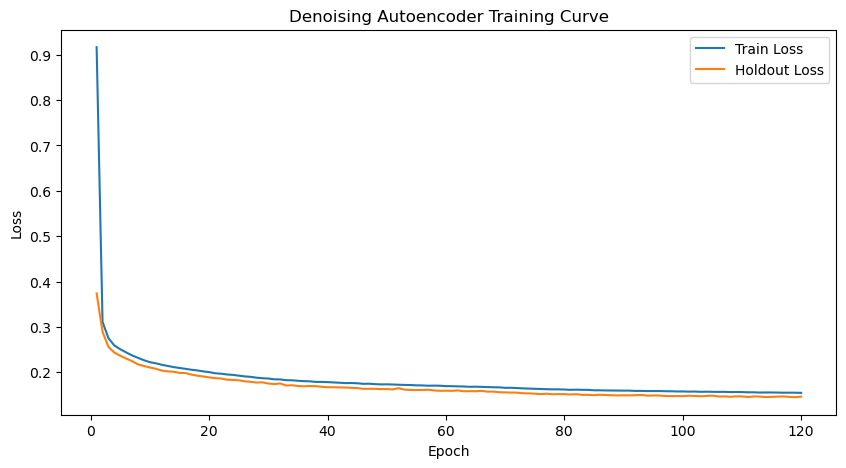

,model,threshold,precision,recall,f1,roc_auc,avg_precision
0,Denoising Deep Autoencoder,-0.223521,0.648685,0.819839,0.724288,0.770946,0.711621


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_ae, X_holdout_ae = train_test_split(
    X_train_scaled,
    test_size=0.10,
    random_state=SEED,
)

class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, 12)
        )

        self.decoder = nn.Sequential(
            nn.Linear(12, 32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),

            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

input_dim = X_train_scaled.shape[1]
ae_model = DenoisingAutoencoder(input_dim).to(device)

criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(
    ae_model.parameters(),
    lr=AE_LEARNING_RATE,
    weight_decay=AE_WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
)

train_tensor = torch.tensor(X_train_ae, dtype=torch.float32)
holdout_tensor = torch.tensor(X_holdout_ae, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

best_state = None
best_holdout_loss = np.inf
epochs_without_improvement = 0
history = []

print("Training denoising autoencoder...")

for epoch in range(AE_EPOCHS):
    ae_model.train()
    train_losses = []

    for batch in train_loader:
        clean_inputs = batch[0].to(device)
        noisy_inputs = clean_inputs + AE_NOISE_STD * torch.randn_like(clean_inputs)

        optimizer.zero_grad()
        outputs = ae_model(noisy_inputs)
        loss = criterion(outputs, clean_inputs)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    ae_model.eval()
    with torch.no_grad():
        holdout_inputs = holdout_tensor.to(device)
        holdout_outputs = ae_model(holdout_inputs)
        holdout_loss = criterion(holdout_outputs, holdout_inputs).item()

    train_loss = float(np.mean(train_losses))
    scheduler.step(holdout_loss)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "holdout_loss": holdout_loss,
    })

    if holdout_loss < best_holdout_loss:
        best_holdout_loss = holdout_loss
        best_state = {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()}
        epochs_without_improvement = 0
        print(f"[Epoch {epoch + 1}/{AE_EPOCHS}] ***New BEST holdout loss: {holdout_loss:.6f}")
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"[Epoch {epoch + 1}/{AE_EPOCHS}] "
            f"train_loss: {train_loss:.6f} | holdout_loss: {holdout_loss:.6f}"
        )

    if epochs_without_improvement >= AE_PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}.")
        break

if best_state is not None:
    ae_model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df.tail())

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["holdout_loss"], label="Holdout Loss")
plt.title("Denoising Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# validation scoring
ae_model.eval()
with torch.no_grad():
    val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    val_reconstructions = ae_model(val_tensor)

    # average squared reconstruction error
    val_recon_error = torch.mean((val_tensor - val_reconstructions) ** 2, dim=1).cpu().numpy()

    # max absolute error sometimes sharpens anomaly ranking
    val_max_abs_error = torch.max(torch.abs(val_tensor - val_reconstructions), dim=1).values.cpu().numpy()

# hybrid reconstruction score
val_scores_ae = 0.7 * robust_zscore(val_recon_error) + 0.3 * robust_zscore(val_max_abs_error)

threshold_info_ae = tune_threshold(
    y_val,
    val_scores_ae,
    objective=THRESHOLD_OBJECTIVE,
    min_recall=MIN_RECALL,
)

ae_val_row = {
    "model": "Denoising Deep Autoencoder",
    "threshold": threshold_info_ae["threshold"],
    "precision": threshold_info_ae["precision"],
    "recall": threshold_info_ae["recall"],
    "f1": threshold_info_ae["f1"],
    **score_summary(y_val, val_scores_ae),
}
display(pd.DataFrame([ae_val_row]))

### Validation comparison

In [ ]:
threshold_if = best_if["threshold"]
val_preds_if = (best_if_scores_val > threshold_if).astype(int)
res_if = evaluate_model(y_val, val_preds_if, "Isolation Forest", "validation")
plot_score_distributions(y_val, best_if_scores_val, "Isolation Forest")
plot_confusion(y_val, val_preds_if, "Isolation Forest - Validation")
summarize_business_view(y_val, val_preds_if)

threshold_lof = best_lof["threshold"]
val_preds_lof = (best_lof_scores_val > threshold_lof).astype(int)
res_lof = evaluate_model(y_val, val_preds_lof, "Local Outlier Factor", "validation")
plot_score_distributions(y_val, best_lof_scores_val, "Local Outlier Factor")
plot_confusion(y_val, val_preds_lof, "Local Outlier Factor - Validation")
summarize_business_view(y_val, val_preds_lof)

threshold_ae = ae_val_row["threshold"]
val_preds_ae = (val_scores_ae > threshold_ae).astype(int)
res_ae = evaluate_model(y_val, val_preds_ae, "Denoising Deep Autoencoder", "validation")
plot_score_distributions(y_val, val_scores_ae, "Denoising Deep Autoencoder")
plot_confusion(y_val, val_preds_ae, "Denoising Deep Autoencoder - Validation")
summarize_business_view(y_val, val_preds_ae)

### Summary

In [46]:
validation_summary = pd.DataFrame([res_if, res_lof, res_ae]).sort_values(
    by=["f1", "recall", "precision"],
    ascending=False,
).reset_index(drop=True)

display(validation_summary)

,model,split,f1,precision,recall
0,Denoising Deep Autoencoder,validation,0.724288,0.648685,0.819839
1,Isolation Forest,validation,0.698012,0.582084,0.871601
2,Local Outlier Factor,validation,0.680830,0.625337,0.747130
